In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.collections import LineCollection
from src.results_paper import *
from src.TimeSeriesAnalysis import *
from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output

In [4]:
results_folder = "../results/TimeSeries/2D"
create_folder(results_folder)

In [ ]:
L_lst   = [512, 1024, 2048]
DIM = 2
NT  = 200
K   = 1.0e-04

NC_list  = [1]
RHO_list = [1.0]
for L in L_lst:
    compute_means_for_folder(L, DIM, NT, K, NC_list, RHO_list)

In [ ]:
process_all_roots("../Data/bond_percolation", verbose=True, clean_outputs=False)
summarize_all_dirs("../Data/bond_percolation", verbose=True)
clear_output()

In [ ]:
df = pd.read_csv("../Data/bond_percolation/all_data_3D.dat", sep=' ').sort_values(by="rho")
df

/tmp/ipykernel_24287/3587901663.py:143: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.82)


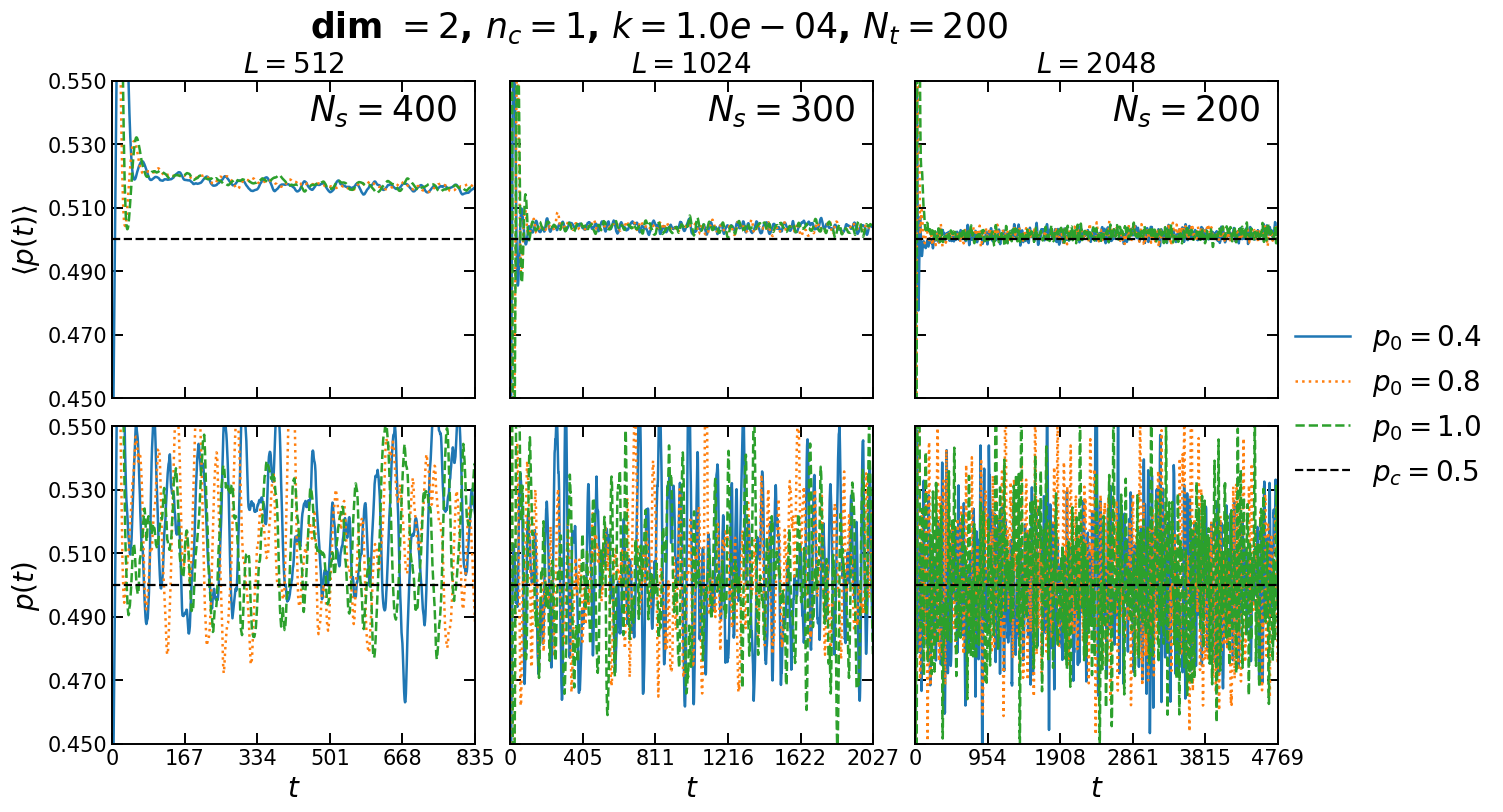

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import LinearLocator, AutoMinorLocator, FormatStrFormatter

def aplicar_ticks(ax, n_xticks=6, n_yticks=6, yfmt='%.3f'):
    ax.xaxis.set_major_locator(LinearLocator(n_xticks))
    ax.yaxis.set_major_locator(LinearLocator(n_yticks))
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    ax.yaxis.set_major_formatter(FormatStrFormatter(yfmt))

# ... suas variáveis (nc_val, k, etc.) ...

ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

# >>> mude para compartilhar x por coluna (não em toda a figura)
fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex='col', sharey=True, constrained_layout=True)
L_list = [512, 1024, 2048]
nc_val = 1
p0_lst = [0.4, 0.8, 1.0]
RHO = 1.0
k = 1.0e-04
pc_ref = 0.50


thickness_axes = 1.4
fs_title = 20
fs_labels = 20
fs_ticks = 15
labels_fig = ["$(a)$", "$(b)$", "$(c)$", "$(d)$", "$(e)$", "$(f)$"]
labels_Ns = ["$N_s = 400$", "$N_s = 300$", "$N_s = 200$"]
legend_lines = {}

# rastreadores por coluna: xmin comum e xmax de sobreposição (min dos max)
col_xmin = [np.inf] * len(L_list)
col_xmax_overlap = [np.inf] * len(L_list)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i_row in range(2):
    for j_col, L in enumerate(L_list):
        ax = axes[i_row, j_col]

        if i_row == 0:
            filename = (
                f"../Data/bond_percolation/num_colors_{nc_val}/dim_2/"
                f"L_{L}/NT_constant/NT_{NT}/k_{k:.1e}/rho_{RHO:.4e}/all_data_bundle.json"
            )
            try:
                df = read_all_data_bundle(filename, as_dataframe=False)
            except Exception:
                ax.text(0.5, 0.5, "arquivo não encontrado\nou erro ao ler",
                        ha='center', va='center', transform=ax.transAxes, fontsize=10)
                ax.set_title(fr"$L={L}$, $n_c={nc_val}$")
                continue

            for idx, p0 in enumerate(p0_lst):
                t = np.asarray(df[p0]['order_percolation_1']['t'])
                pt = np.asarray(df[p0]['order_percolation_1']['pt'])
                if t.size == 0:
                    continue

                line, = ax.plot(t, pt, lw=1.8, ls=ls[idx], color=colors[idx])

                # guarda um handle para a legenda global
                if p0 not in legend_lines:         # <-- antes era if idx not in legend_lines
                    legend_lines[p0] = line

                # atualiza limites por coluna
                col_xmin[j_col] = min(col_xmin[j_col], float(np.nanmin(t)))
                col_xmax_overlap[j_col] = min(col_xmax_overlap[j_col], float(np.nanmax(t)))

        else:
            for idx, p0 in enumerate(p0_lst):
                path = (f"../Data/bond_percolation/num_colors_{nc_val}/dim_2/"
                        f"L_{L}/NT_constant/NT_{NT}/k_{k:.1e}/rho_{RHO:.4e}/data/")
                file = select_random_json(path, p0=p0)
                if not file:
                    continue
                ts = read_experiment_json(file)

                t = np.asarray(ts['results']['order_percolation 1']['data']['time'])
                pt = np.asarray(ts['results']['order_percolation 1']['data']['pt'])
                if t.size == 0:
                    continue

                ax.plot(t, pt, lw=1.8, ls=ls[idx], color=colors[idx])

                # atualiza limites por coluna (sobreposição = min dos max)
                col_xmin[j_col] = min(col_xmin[j_col], float(np.nanmin(t)))
                col_xmax_overlap[j_col] = min(col_xmax_overlap[j_col], float(np.nanmax(t)))

        
        
        
        if i_row == 0:
            if j_col ==0:
                ax.set_ylabel(r'$\langle p(t) \rangle$', fontsize=fs_labels)
            
            ax.text(0.95, 0.85, labels_Ns[j_col],
                    transform=ax.transAxes, ha='right', va='bottom', fontsize=25)
            ax.set_title(fr"$L={L}$", fontsize=fs_title)
        
        if i_row == 1:
            if j_col == 0:
                ax.set_ylabel(r'$p(t)$', fontsize=fs_labels)
            
            ax.set_xlabel(r'$t$', fontsize=fs_labels)

        ax.set_ylim(0.45, 0.55)
        ax.axhline(y=pc_ref, ls='--', lw=1.6, color='k')
        ax.tick_params(axis='both', which='major',
            length=8, width=thickness_axes, direction='in', labelsize=fs_ticks)

        # Minor ticks: geralmente menores/mais finos
        ax.tick_params(axis='both', which='minor',
                    length=4, width=thickness_axes, direction='in')

        for spine in ax.spines.values():
            spine.set_linewidth(thickness_axes)

# === Ajusta os limites de X por coluna, garantindo as 3 curvas visíveis ===
for j_col in range(len(L_list)):
    xmin = col_xmin[j_col]
    xmax = col_xmax_overlap[j_col]
    if np.isfinite(xmin) and np.isfinite(xmax) and xmax > xmin:
        for i_row in range(2):
            ax = axes[i_row, j_col]
            ax.set_xlim(xmin, xmax)
            aplicar_ticks(ax, n_xticks=6, n_yticks=6)  # ticks DEPOIS do set_xlim
            # rótulos conforme sua lógica
            if i_row == 0:
                ax.tick_params(axis='x', which='both', labelbottom=False)
            else:
                ax.tick_params(axis='x', which='both', labelbottom=True)
            if j_col != 0:
                ax.tick_params(axis='y', which='both', labelleft=False)

# ===== legenda global =====
fig.subplots_adjust(right=0.82)

handles = [legend_lines[p] for p in p0_lst if p in legend_lines]
labels  = [fr'$p_0 = {p:.1f}$' for p in p0_lst if p in legend_lines]

pc_handle = Line2D([0], [0], linestyle='--', linewidth=1.6, color='k')
handles.append(pc_handle)
labels.append(fr'$p_c = {pc_ref}$')

leg = fig.legend(handles, labels,
                 loc='center left', bbox_to_anchor=(0.97, 0.5),  # empurra um pouco mais p/ fora
                 frameon=False, fontsize=20)

fig.suptitle(fr"dim $= 2$, $n_c = {nc_val}$, $k = {k:.1e}$, $N_t = {NT}$",
             fontsize=25, fontweight='bold')

# Desenha o layout antes de salvar (importante p/ cálculo do bbox)
fig.canvas.draw()

plt.savefig(results_folder + "/1_color/TimeSeries_L_single_multi_samples.pdf",
            bbox_inches='tight', pad_inches=0.1)   # <-- evita corte da legenda
plt.show()

In [ ]:
L_lst   = [2048, 4096, 8192]
DIM = 2
NT  = 400
K   = 1.0e-05

NC_list  = [2, 4 ,8]
RHO_list = [0.125]
for L in L_lst:
    compute_means_for_folder(L, DIM, NT, K, NC_list, RHO_list)

TypeError: 'int' object is not iterable